In [1]:
from qiskit import * 
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.transpiler.passes import RemoveBarriers
from qiskit.visualization import plot_histogram
from IPython.display import display
%matplotlib inline

C:\Users\gt_96\AppData\Local\Temp\ipykernel_22052\1263494379.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import *


In [2]:
# PARAMS

# grid dimension
N = 4

# data register len
n = 8

# solution len
M = 2

In [3]:
# EXECUTION (Aer QASM simulation)
def execution(qc, shots=1024):
    backend = AerSimulator()
    qc_compiled = transpile(qc, backend)
    job = backend.run(qc_compiled, shots=shots)
    result = job.result()
    counts = result.get_counts()
    
    return counts

In [4]:
# DIFFUSER
def diffuser(dif_qc):
    dif_qc.h(range(n))
    dif_qc.x(range(n))

    dif_qc.barrier(range(n))

    dif_qc.h(n-1)
    dif_qc.mcx(list(range(n-1)), n-1)
    dif_qc.h(n-1)

    dif_qc.barrier(range(n))

    dif_qc.x(range(n))
    dif_qc.h(range(n))

    return dif_qc

In [5]:
# BITWISE qXOR OPERATOR
def bitwise_qxor(qc): 
    qc.cx(0,4)
    qc.cx(2,4)
   
    qc.cx(1,5)
    qc.cx(3,5)

    return qc

In [6]:
# COL CHECK OPERATOR
def col_check(qc):
    qc.x(0)
    qc.x(1)
    qc.ccx(0,1,2) # collision if equal
    qc.x(1)
    qc.x(0)
    
    return qc

In [7]:
# COL EQ OPERATOR
def col_eq(qc):
    
    # bitwise qXOR operator
    bw_qxor_qc = bitwise_qxor(QuantumCircuit(6))

    # column check operator
    col_check_qc = col_check(QuantumCircuit(3))


    ## QO ---

    # Q0 --- Q1
    qc.compose(bw_qxor_qc, [0,1,2,3,8,9],inplace=True)          # Q0 qXOR Q1 local compute
    qc.barrier(range(8,17))
    qc.compose(col_check_qc,[8,9,10],inplace=True)              # Q0 eq Q1 local compute
    qc.barrier(range(8,17))
    qc.cx(10,11)                                                # local target action
    qc.barrier(range(8,17))
    qc.compose(col_check_qc.inverse(),[8,9,10],inplace=True)    # Q0 eq Q1 local uncompute
    qc.barrier(range(8,17))
    qc.compose(bw_qxor_qc.inverse(),[0,1,2,3,8,9],inplace=True) # Q0 qXOR Q1 local uncompute

    qc.barrier()
    
    # Q0 --- Q2
    qc.compose(bw_qxor_qc,[0,1,4,5,8,9],inplace=True)           # Q0 qXOR Q2 local compute
    qc.barrier(range(8,17))
    qc.compose(col_check_qc,[8,9,10],inplace=True)              # Q0 eq Q2 local compute
    qc.barrier(range(8,17))
    qc.cx(10,12)                                                # local target action
    qc.barrier(range(8,17))
    qc.compose(col_check_qc.inverse(),[8,9,10],inplace=True)    # Q0 eq Q2 local uncompute
    qc.barrier(range(8,17))
    qc.compose(bw_qxor_qc.inverse(),[0,1,4,5,8,9],inplace=True) # Q0 qXOR Q2 local uncompute

    qc.barrier()
    
    # Q0 --- Q3
    qc.compose(bw_qxor_qc,[0,1,6,7,8,9],inplace=True)           # Q0 qXOR Q3 local compute
    qc.barrier(range(8,17))
    qc.compose(col_check_qc,[8,9,10],inplace=True)              # Q0 eq Q3 local compute
    qc.barrier(range(8,17))
    qc.cx(10,13)                                                # local target action
    qc.barrier(range(8,17))
    qc.compose(col_check_qc.inverse(),[8,9,10],inplace=True)    # Q0 eq Q3 local uncompute
    qc.barrier(range(8,17))
    qc.compose(bw_qxor_qc.inverse(),[0,1,6,7,8,9],inplace=True) # Q0 qXOR Q3 local uncompute

    qc.barrier()

    ##

    ## Q1 ---

    # Q1 --- Q2
    qc.compose(bw_qxor_qc,[2,3,4,5,8,9],inplace=True)           # Q1 qXOR Q2 local compute        
    qc.barrier(range(8,17))
    qc.compose(col_check_qc,[8,9,10],inplace=True)              # Q1 eq Q2 local compute
    qc.barrier(range(8,17))
    qc.cx(10,14)                                                # local target action
    qc.barrier(range(8,17))
    qc.compose(col_check_qc.inverse(),[8,9,10],inplace=True)    # Q1 eq Q2 local uncompute
    qc.barrier(range(8,17))
    qc.compose(bw_qxor_qc.inverse(),[2,3,4,5,8,9],inplace=True) # Q1 qXOR Q2 local uncompute  

    qc.barrier()

    # Q1 --- Q3
    qc.compose(bw_qxor_qc,[2,3,6,7,8,9],inplace=True)           # Q1 qXOR Q3 local compute     
    qc.barrier(range(8,17))
    qc.compose(col_check_qc,[8,9,10],inplace=True)              # Q1 eq Q3 local compute
    qc.barrier(range(8,17))
    qc.cx(10,15)                                                # local target action
    qc.barrier(range(8,17))
    qc.compose(col_check_qc.inverse(),[8,9,10],inplace=True)    # Q1 eq Q3 local uncompute
    qc.barrier(range(8,17))
    qc.compose(bw_qxor_qc.inverse(),[2,3,6,7,8,9],inplace=True) # Q1 qXOR Q3 local uncompute 

    qc.barrier()

    ##

    ## Q2 ---

    # Q2 --- Q3
    qc.compose(bw_qxor_qc,[4,5,6,7,8,9],inplace=True)           # Q2 qXOR Q3 local compute     
    qc.barrier(range(8,17))
    qc.compose(col_check_qc,[8,9,10],inplace=True)              # Q2 eq Q3 local compute
    qc.barrier(range(8,17))
    qc.cx(10,16)                                                # local target action
    qc.barrier(range(8,17))
    qc.compose(col_check_qc.inverse(),[8,9,10],inplace=True)    # Q2 eq Q3 local uncompute
    qc.barrier(range(8,17))
    qc.compose(bw_qxor_qc.inverse(),[4,5,6,7,8,9],inplace=True) # Q2 qXOR Q3 local uncompute 

    ##

    return qc

In [8]:
# DIAG CHECK OPERATOR
def diag_check(qc):
    qc.x(0)
    qc.x(1)
    qc.x(2)
    qc.mcx(list(range(3)),3) # collision if equal and no overflow
    qc.x(2)
    qc.x(1)
    qc.x(0)
    
    return qc

In [9]:
# INCREMENTER OPERATOR
def incrementer(qc):
    qc.ccx(0,1,2) # overflow check
    qc.cx(0,1)
    qc.x(0)

    return qc

In [10]:
# FANOUT OPERATOR
def fanout(qc):
    qc.cx(0,2)
    qc.cx(1,3)

    return qc

In [11]:
# DIAG EQ OPERATOR
def diag_eq(qc, ctr_qc):

    # fanout operator
    fanout_qc = fanout(QuantumCircuit(4))

    # bitwise qXOR operator
    bw_qxor_qc = bitwise_qxor(QuantumCircuit(6))

    # diag check operator
    diag_check_qc = diag_check(QuantumCircuit(4))


    ## Q0 ---

    # QO fanout local compute
    qc.compose(fanout_qc,[0,1,8,9],inplace=True)

    qc.barrier()

    # Q0 +/- 1 local compute 
    qc.compose(ctr_qc,[8,9,10],inplace=True)                      
    
    # Q0 +/- 1 --- Q1
    qc.barrier()
    qc.compose(bw_qxor_qc,[2,3,8,9,11,12],inplace=True)             # (Q0 +/- 1) qXOR Q1 local compute            
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc,[10,11,12,13],inplace=True)            # (Q0 +/- 1) eq Q1 local compute
    qc.barrier(range(10,20))
    qc.cx(13,14)                                                    # local action
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc.inverse(),[10,11,12,13],inplace=True)  # (Q0 +/- 1) eq Q1 local uncompute
    qc.barrier(range(10,20))
    qc.compose(bw_qxor_qc.inverse(),[2,3,8,9,11,12],inplace=True)   # (Q0 +/- 1) qXOR Q1 local uncompute 
    qc.barrier()

    # Q0 +/- 2 local compute
    qc.compose(ctr_qc,[8,9,10],inplace=True)

    # Q0 +/- 2 --- Q2
    qc.barrier()
    qc.compose(bw_qxor_qc,[4,5,8,9,11,12],inplace=True)             # (Q0 +/- 2) qXOR Q2 local compute 
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc,[10,11,12,13],inplace=True)            # (Q0 +/- 2) eq Q2 local compute
    qc.barrier(range(10,20))
    qc.cx(13,15)                                                    # local action
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc.inverse(),[10,11,12,13],inplace=True)  # (Q0 +/- 2) eq Q2 local uncompute
    qc.barrier(range(10,20))
    qc.compose(bw_qxor_qc.inverse(),[4,5,8,9,11,12],inplace=True)   # (Q0 +/- 2) qXOR Q2 local uncompute 
    qc.barrier()

    # Q0 +/- 3 local compute
    qc.compose(ctr_qc,[8,9,10],inplace=True)                       

    # Q0 +/- 3 --- Q3
    qc.barrier()
    qc.compose(bw_qxor_qc,[6,7,8,9,11,12],inplace=True)             # (Q0 +/- 3) qXOR Q3 local compute 
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc,[10,11,12,13],inplace=True)            # (Q0 +/- 3) eq Q3 local compute
    qc.barrier(range(10,20))
    qc.cx(13,16)                                                    # local action
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc.inverse(),[10,11,12,13],inplace=True)  # (Q0 +/- 3) eq Q3 local uncompute
    qc.barrier(range(10,20))
    qc.compose(bw_qxor_qc.inverse(),[6,7,8,9,11,12],inplace=True)   # (Q0 +/- 3) qXOR Q3 local uncompute 
    qc.barrier()
    
    # Q0 +/- 3 local uncompute
    qc.compose(ctr_qc.inverse(),[8,9,10],inplace=True)

    qc.barrier()

    # Q0 +/- 2 local uncompute
    qc.compose(ctr_qc.inverse(),[8,9,10],inplace=True)

    qc.barrier()
    
    # Q0 +/- 1 local uncompute
    qc.compose(ctr_qc.inverse(),[8,9,10],inplace=True)

    qc.barrier()

    # QO fanout local uncompute
    qc.compose(fanout_qc.inverse(),[0,1,8,9],inplace=True)

    qc.barrier()

    ##

    ## Q1 ---

    # Q1 fanout local compute
    qc.compose(fanout_qc,[2,3,8,9],inplace=True)

    qc.barrier()
    
    # Q1 +/- 1 local compute
    qc.compose(ctr_qc,[8,9,10],inplace=True)

    # Q1 +/- 1 --- Q2
    qc.barrier()
    qc.compose(bw_qxor_qc,[4,5,8,9,11,12],inplace=True)             # (Q1 +/- 1) qXOR Q2 local compute 
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc,[10,11,12,13],inplace=True)            # (Q1 +/- 1) eq Q2 local compute
    qc.barrier(range(10,20))
    qc.cx(13,17)                                                    # local action
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc.inverse(),[10,11,12,13],inplace=True)  # (Q1 +/- 1) eq Q2 local uncompute
    qc.barrier(range(10,20))
    qc.compose(bw_qxor_qc.inverse(),[4,5,8,9,11,12],inplace=True)   # (Q1 +/- 1) qXOR Q2 local uncompute
    qc.barrier()

    # Q1 +/- 2 local compute
    qc.compose(ctr_qc,[8,9,10],inplace=True)

    # Q1 +/- 2 --- Q3
    qc.barrier()
    qc.compose(bw_qxor_qc,[6,7,8,9,11,12],inplace=True)             # (Q1 +/- 2) qXOR Q3 local compute
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc,[10,11,12,13],inplace=True)            # (Q1 +/- 2) eq Q3 local compute
    qc.barrier(range(10,20))
    qc.cx(13,18)                                                    # local action
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc.inverse(),[10,11,12,13],inplace=True)  # (Q1 +/- 2) eq Q3 local uncompute
    qc.barrier(range(10,20))
    qc.compose(bw_qxor_qc.inverse(),[6,7,8,9,11,12],inplace=True)   # (Q1 +/- 2) qXOR Q3 local uncompute
    qc.barrier()

    # Q1 +/- 2 local uncompute
    qc.compose(ctr_qc.inverse(),[8,9,10],inplace=True)

    qc.barrier()

    # Q1 +/- 1 local uncompute
    qc.compose(ctr_qc.inverse(),[8,9,10],inplace=True)

    qc.barrier()

    # Q1 fanout local uncompute
    qc.compose(fanout_qc.inverse(),[2,3,8,9],inplace=True)

    qc.barrier()

    ##

    ## Q2 ---

    # Q2 fanout local compute
    qc.compose(fanout_qc,[4,5,8,9],inplace=True)

    qc.barrier()
    
    # Q2 +/- 1 local compute
    qc.compose(ctr_qc,[8,9,10],inplace=True)

    # Q2 +/- 1 --- Q3
    qc.barrier()
    qc.compose(bw_qxor_qc,[6,7,8,9,11,12],inplace=True)                 # (Q2 +/- 1) qXOR Q3 local compute
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc,[10,11,12,13],inplace=True)                # (Q2 +/- 1) eq Q3 local compute
    qc.barrier(range(10,20))
    qc.cx(13,19)                                                        # local action
    qc.barrier(range(10,20))
    qc.compose(diag_check_qc.inverse(),[10,11,12,13],inplace=True)      # (Q2 +/- 1) eq Q3 local uncompute
    qc.barrier(range(10,20))
    qc.compose(bw_qxor_qc.inverse(),[6,7,8,9,11,12],inplace=True)       # (Q2 +/- 1) qXOR Q3 local uncompute
    qc.barrier()

    # Q2 +/- 1 local uncompute
    qc.compose(ctr_qc.inverse(),[8,9,10],inplace=True)

    qc.barrier()

    # Q2 fanout local uncompute
    qc.compose(fanout_qc.inverse(),[4,5,8,9],inplace=True)

    ##

    return qc

In [12]:
# COL EQ CONJUGATION (compute-action-uncompute)
def col_eq_conj(qc):

    # col eq operator
    col_eq_qc = col_eq(QuantumCircuit(17))


    # local compute     
    qc.compose(col_eq_qc,list(range(17)),inplace=True)  

    # test local action 
    qc.barrier()
    qc.barrier(range(11,21))
    qc.x(range(11,17))                                              
    qc.mcx(list(range(11,17)),20)                                                           
    qc.x(range(11,17))                                             
    qc.barrier(range(11,21))
    qc.barrier()

    # local uncompute
    qc.compose(col_eq_qc.inverse(),list(range(17)),inplace=True)    

    return qc

In [13]:
# DIAG DIFF EQ CONJUGATION (compute-action-uncompute)
# diag \ : Ri-Ci=Rj-Cj, i=[0,3], j=[0,3], i=/=j            
def diag_diff_eq_conj(qc):

    # incrementer operator
    incr_qc = incrementer(QuantumCircuit(3))

    # diag diff eq operator
    diag_diff_eq_qc = diag_eq(QuantumCircuit(20),incr_qc)
    
    
    # local compute
    qc.compose(diag_diff_eq_qc,list(range(20)),inplace=True)                         
   
    # test local action
    qc.barrier()
    qc.barrier(range(14,23))
    qc.x(range(14,20))                                              
    qc.mcx(list(range(14,20)),21)                                                              
    qc.x(range(14,20))                                              
    qc.barrier(range(14,23))
    qc.barrier()

    # local uncompute
    qc.compose(diag_diff_eq_qc.inverse(),list(range(20)),inplace=True)  

    return qc

In [14]:
# DIAG SUM EQ CONJUGATION (compute-action-uncompute)
# diag / : Ri+Ci=Rj+Cj, i=[0,3], j=[0,3], i=/=j   
def diag_sum_eq_conj(qc):

    # decrementer operator
    decr_qc = incrementer(QuantumCircuit(3)).inverse()

    # diag sum eq operator
    diag_sum_eq_qc = diag_eq(QuantumCircuit(20),decr_qc)


    # local compute
    qc.compose(diag_sum_eq_qc,list(range(20)),inplace=True)                         
   
    # test local action
    qc.barrier()
    qc.barrier(range(14,23))
    qc.x(range(14,20))                                              
    qc.mcx(list(range(14,20)),22)                                                              
    qc.x(range(14,20))                                              
    qc.barrier(range(14,23))
    qc.barrier()

    # local uncompute
    qc.compose(diag_sum_eq_qc.inverse(),list(range(20)),inplace=True)  

    return qc

In [15]:
# DIAG EQ CONJUGATION
# diag: |ri-rj|=|ci-cj|, i=[0,3], j=[0,3], i=/=j
def diag_eq_conj(qc): 

    # diag diff eq conj operator
    diag_diff_eq_conj_qc = diag_diff_eq_conj(QuantumCircuit(23))

    # diag sum eq conj operator
    diag_sum_eq_conj_qc = diag_sum_eq_conj(QuantumCircuit(23))


    # diag diff eq conj
    qc.compose(diag_diff_eq_conj_qc,range(23),inplace=True)
    
    # diag sum eq conj
    qc.compose(diag_sum_eq_conj_qc,range(23),inplace=True)

    return qc

In [16]:
# ORACLE
def oracle(qc):
    
    # col eq conj operator
    col_eq_conj_qc = col_eq_conj(QuantumCircuit(23))

    # diag eq conj operator
    diag_eq_conj_qc = diag_eq_conj(QuantumCircuit(23))


    # col eq conj compute
    qc.compose(col_eq_conj_qc,list(range(23)),inplace=True)
    
    # diag eq conj compute
    qc.compose(diag_eq_conj_qc,list(range(23)),inplace=True)
 
    # test action
    qc.barrier()
    qc.barrier()
    qc.barrier(range(20,24))
    qc.mcx(list(range(20,23)),23) # true if no collision detected
    qc.barrier(range(20,24))
    qc.barrier()
    qc.barrier()

    # diag eq conj uncompute
    qc.compose(diag_eq_conj_qc.inverse(),list(range(23)),inplace=True)

    # col eq conj uncompute
    qc.compose(col_eq_conj_qc.inverse(),list(range(23)),inplace=True)

    return qc

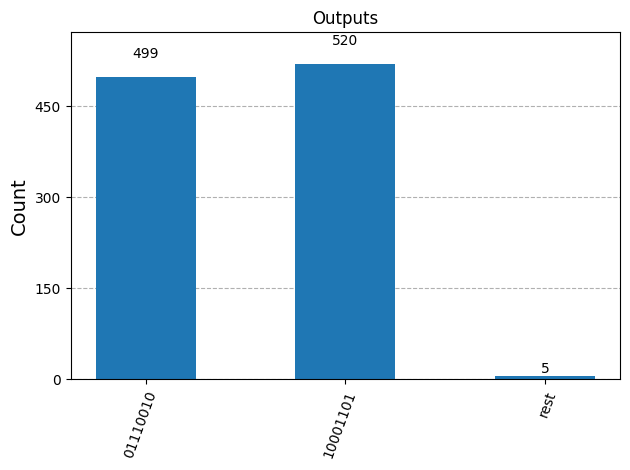

In [17]:
def queens_problem():
    
    # circuit
    qc = QuantumCircuit(QuantumRegister(2,'Q0'), QuantumRegister(2,'Q1'), QuantumRegister(2,'Q2'), QuantumRegister(2,'Q3'), QuantumRegister(16,'A'), ClassicalRegister(8,'Cbits'))

    # H on data register
    qc.h(range(n))

    # X-H on last ancilla
    qc.x(23)
    qc.h(23)

    qc.barrier()

    # optimal iterations
    iterations = int(np.round(np.pi / (4 * np.arcsin(np.sqrt(M / (2**n)))) - 0.5))
    
    # oracle
    oracle_qc = oracle(QuantumCircuit(24))
    oracle_gate = RemoveBarriers()(oracle_qc).to_gate(label='Oracle')

    # diffuser
    dif_qc = diffuser(QuantumCircuit(n))
    dif_gate = RemoveBarriers()(dif_qc).to_gate(label='Diffuser')

    # oracle + diffuser iterations
    for i in range(iterations):
        if i == 0:
            qc.compose(oracle_qc, range(24), inplace=True)
        else:
            qc.compose(oracle_gate, range(24), inplace=True)
        qc.barrier()

        qc.compose(dif_gate, range(n), inplace=True)
        qc.barrier(range(n))

    # measurement
    qc.measure(range(n), range(n))

    return qc

qc = queens_problem()

counts = execution(qc)

display(qc.draw('mpl', fold=75))

plot_histogram(counts, number_to_keep=M, title='Outputs')

In [18]:
# PRINT BOARDS

def print_boards(counts):

    solutions = sorted(counts, key=counts.get, reverse=True)[:M]
    solutions = sorted(solutions, key=lambda item: int(item, 2))
    
    for i, solution in enumerate(solutions):
        
        columns = [int(solution[-n:][j:j+2], 2) for j in range(0, n, 2)][::-1]
        
        print(f"\nSolution {i+1}: {columns}\n")
        
        for r in range(N):
            line = " ".join("♛" if columns[r] == c else "·" for c in range(N))
            print(f"| {line} |")
        
        print()


print_boards(counts)


Solution 1: [2, 0, 3, 1]

| · · ♛ · |
| ♛ · · · |
| · · · ♛ |
| · ♛ · · |


Solution 2: [1, 3, 0, 2]

| · ♛ · · |
| · · · ♛ |
| ♛ · · · |
| · · ♛ · |

